In [1]:
import pandas as pd
import numpy as np



In [2]:
df = pd.read_csv('D:\Machine Learning\Smart-Irrigation-Project\Data\processed\smart_irrigation_cleaned.csv')
df.head()

,growth_stage,temperature,humidity,rainfall,forecast_rainfall,wind_speed,solar_radiation,pressure,cloud_cover,dew_point,...,crop_type_Sugarcane,crop_type_Wheat,region_North,region_South,region_West,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_type_Flood,irrigation_type_Sprinkler
0,3,30.11,56.83,244.37,25.49,16.22,494.42,956.28,18.19,7.38,...,0,0,0,0,0,1,0,0,0,0
1,2,16.98,33.83,77.67,7.17,14.98,958.41,971.66,49.19,28.17,...,0,0,0,0,1,0,0,1,0,1
2,2,41.51,56.24,241.26,38.82,4.25,944.36,1022.92,2.19,16.81,...,1,0,1,0,0,0,0,0,0,1
3,3,37.59,34.14,124.00,73.21,3.65,712.11,976.40,35.25,23.10,...,0,0,0,0,0,0,0,0,0,0
4,2,26.36,72.79,79.94,21.39,3.91,995.69,970.73,5.53,22.34,...,0,0,0,0,0,0,1,0,0,0


In [3]:
# Target
y = df["future_soil_moisture_3day"]

# Remove target and other prediction targets
X = df.drop(columns=[
    "future_soil_moisture_3day",
    "yield_prediction",
    "crop_health_index",
    "water_quantity_required_liters",
    "irrigation_required"
])

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (10000, 43)
Y Shape: (10000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 43)
(2000, 43)


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr = LinearRegression()

lr.fit(X_train, y_train)

train_pred_lr = lr.predict(X_train)
test_pred_lr = lr.predict(X_test)

print("Linear Regression")

print("Training r2 score Is:",
      round(r2_score(y_train, train_pred_lr),4))

print("Testing r2 score Is:",
      round(r2_score(y_test, test_pred_lr),4))

print("R2 score gap Is:",
      round(
          r2_score(y_train, train_pred_lr)
          -
          r2_score(y_test, test_pred_lr),
          4
      ))

mae = mean_absolute_error(y_test,test_pred_lr)
mse = mean_squared_error(y_test,test_pred_lr)
rmse = np.sqrt(mse)

print("MAE :", round(mae,4))
print("MSE :", round(mse,4))
print("RMSE :", round(rmse,4))

Linear Regression
Training r2 score Is: 1.0
Testing r2 score Is: 1.0
R2 score gap Is: -0.0
MAE : 0.0025
MSE : 0.0
RMSE : 0.0029


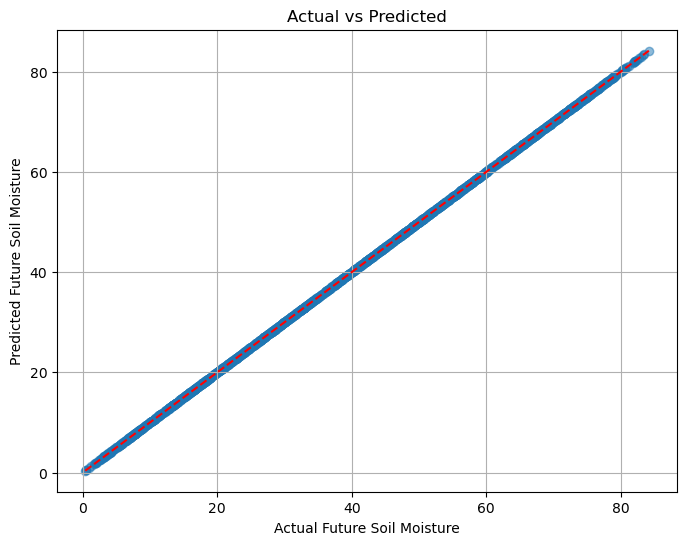

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    test_pred_lr,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Future Soil Moisture")
plt.ylabel("Predicted Future Soil Moisture")

plt.title("Actual vs Predicted")

plt.grid()

plt.show()

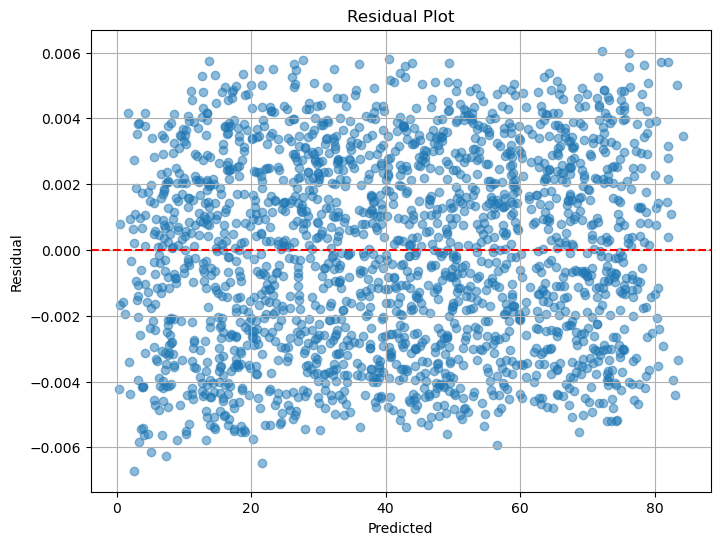

In [7]:
residuals = y_test - test_pred_lr

plt.figure(figsize=(8,6))

plt.scatter(
    test_pred_lr,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid()

plt.show()

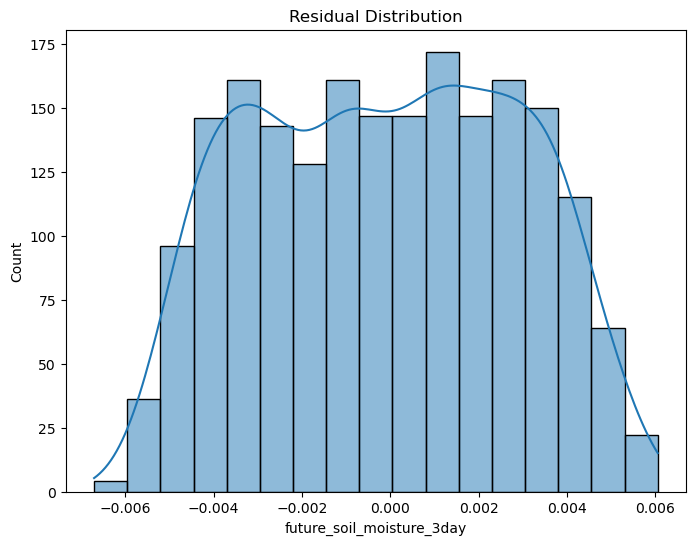

In [8]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

In [9]:
coef_df = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": lr.coef_

})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient
10,soil_moisture,9.999934e-01
4,forecast_rainfall,7.999046e-02
37,region_West,5.150645e-04
33,crop_type_Sugarcane,2.358777e-04
35,region_North,2.107575e-04
12,soil_ph,1.424212e-04
17,ec,1.255652e-04
36,region_South,1.122578e-04
34,crop_type_Wheat,9.046942e-05
0,growth_stage,6.234107e-05


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

train_pred_rf = rf.predict(X_train)
test_pred_rf = rf.predict(X_test)

print("Random Forest")

print("Training r2 score Is:",
      round(r2_score(y_train, train_pred_rf),4))

print("Testing r2 score Is:",
      round(r2_score(y_test, test_pred_rf),4))

print("MAE :",
      round(mean_absolute_error(y_test,test_pred_rf),4))

print("RMSE :",
      round(
          np.sqrt(
              mean_squared_error(
                  y_test,
                  test_pred_rf
              )
          ),4
      ))

Random Forest
Training r2 score Is: 0.9999
Testing r2 score Is: 0.9994
MAE : 0.4241
RMSE : 0.544


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,15,None],

    "min_samples_split":[2,5,10]

}

grid_rf = GridSearchCV(

    RandomForestRegressor(
        random_state=42
    ),

    param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1
)

grid_rf.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_rf.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}


In [12]:
best_rf_tune = grid_rf.best_estimator_
print("\nBest r2 Score:")
print(round(grid_rf.best_score_, 4))


Best r2 Score:
0.9993


In [13]:
train_pred_rf_tune = best_rf_tune.predict(X_train)
test_pred_rf_tune  = best_rf_tune.predict(X_test)

In [14]:
train_r2_rf_tune = r2_score(y_train, train_pred_rf_tune)

train_mae_rf_tune = mean_absolute_error(y_train,train_pred_rf_tune )

train_mse_rf_tune = mean_squared_error(y_train, train_pred_rf_tune)

train_rmse_rf_tune = train_mse_rf_tune ** 0.5

print("===== Training Metrics =====")
print("R² Score :", round(train_r2_rf_tune,4))
print("MAE      :", round(train_mae_rf_tune,4))
print("MSE      :", round(train_mse_rf_tune,4))
print("RMSE     :", round(train_rmse_rf_tune,4))



test_r2_rf_tune = r2_score(y_test, test_pred_rf_tune)

test_mae_rf_tune = mean_absolute_error(y_test, test_pred_rf_tune)

test_mse_rf_tune = mean_squared_error(y_test, test_pred_rf_tune)

test_rmse_rf_tune = test_mse_rf_tune ** 0.5

print("\n===== Testing Metrics =====")
print("R² Score :", round(test_r2_rf_tune,4))
print("MAE      :", round(test_mae_rf_tune,4))
print("MSE      :", round(test_mse_rf_tune,4))
print("RMSE     :", round(test_rmse_rf_tune,4))

===== Training Metrics =====
R² Score : 0.9999
MAE      : 0.1544
MSE      : 0.0395
RMSE     : 0.1987

===== Testing Metrics =====
R² Score : 0.9994
MAE      : 0.4249
MSE      : 0.2968
RMSE     : 0.5448


In [15]:
r2_gap_rf_tune = train_r2_rf_tune - test_r2_rf_tune

print("\nR² Score Gap Is:",
      round(r2_gap_rf_tune,4))


R² Score Gap Is: 0.0005


In [16]:
feature_importance_rf_tune = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_tune.feature_importances_
})

feature_importance_rf_tune = feature_importance_rf_tune.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_rf_tune.head(10))

                    Feature  Importance
10            soil_moisture    0.986012
4         forecast_rainfall    0.010264
1               temperature    0.002874
30  crop_water_stress_level    0.000045
8               cloud_cover    0.000031
6           solar_radiation    0.000031
16           organic_matter    0.000031
20                     ndvi    0.000030
26        groundwater_level    0.000030
5                wind_speed    0.000030


# **XGBoost**

In [18]:
from xgboost import XGBRegressor

xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

train_pred_xgb = xgb.predict(X_train)
test_pred_xgb = xgb.predict(X_test)



print("Training r2 score Is:",
      round(r2_score(y_train, train_pred_xgb),4))

print("Testing r2 score Is:",
      round(r2_score(y_test, test_pred_xgb),4))

print("MAE :",
      round(mean_absolute_error(y_test,test_pred_xgb),4))

print("RMSE :",
      round(
          np.sqrt(
              mean_squared_error(
                  y_test,
                  test_pred_xgb
              )
          ),4
      ))

Training r2 score Is: 0.9999
Testing r2 score Is: 0.9998
MAE : 0.2293
RMSE : 0.2923


In [19]:
param_grid = {

    "n_estimators":[100,200],

    "max_depth":[4,6,8],

    "learning_rate":[0.01,0.05,0.1]

}

grid_xgb = GridSearchCV(

    XGBRegressor(
        random_state=42
    ),

    param_grid,

    cv=3,

    scoring="r2",

    n_jobs=-1
)

grid_xgb.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_xgb.best_params_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}


In [20]:
best_xgb_tune = grid_xgb.best_estimator_
print("\nBest r2 Score:")
print(round(grid_rf.best_score_, 4))


Best r2 Score:
0.9993


In [21]:
train_pred_xg_tune = best_xgb_tune.predict(X_train)
test_pred_xg_tune  = best_xgb_tune.predict(X_test)

In [22]:
train_r2_xg_tune = r2_score(y_train, train_pred_xg_tune)

train_mae_xg_tune = mean_absolute_error(y_train,train_pred_xg_tune )

train_mse_xg_tune = mean_squared_error(y_train, train_pred_xg_tune)

train_rmse_xg_tune = train_mse_xg_tune ** 0.5

print("===== Training Metrics =====")
print("R² Score :", round(train_r2_xg_tune,4))
print("MAE      :", round(train_mae_xg_tune,4))
print("MSE      :", round(train_mse_xg_tune,4))
print("RMSE     :", round(train_rmse_xg_tune,4))



test_r2_xg_tune = r2_score(y_test, test_pred_xg_tune)

test_mae_xg_tune = mean_absolute_error(y_test, test_pred_xg_tune)

test_mse_xg_tune = mean_squared_error(y_test, test_pred_xg_tune)

test_rmse_xg_tune = test_mse_xg_tune ** 0.5

print("\n===== Testing Metrics =====")
print("R² Score :", round(test_r2_xg_tune,4))
print("MAE      :", round(test_mae_xg_tune,4))
print("MSE      :", round(test_mse_xg_tune,4))
print("RMSE     :", round(test_rmse_xg_tune,4))

===== Training Metrics =====
R² Score : 0.9999
MAE      : 0.141
MSE      : 0.0332
RMSE     : 0.1821

===== Testing Metrics =====
R² Score : 0.9998
MAE      : 0.2318
MSE      : 0.0871
RMSE     : 0.2951


In [23]:
r2_gap_xg_tune = train_r2_xg_tune - test_r2_xg_tune

print("\nR² Score Gap Is:",
      round(r2_gap_xg_tune,4))


R² Score Gap Is: 0.0001


In [24]:
feature_importance_xg_tune = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb_tune.feature_importances_
})

feature_importance_rf_tune = feature_importance_rf_tune.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_rf_tune.head(10))

                    Feature  Importance
10            soil_moisture    0.986012
4         forecast_rainfall    0.010264
1               temperature    0.002874
30  crop_water_stress_level    0.000045
8               cloud_cover    0.000031
6           solar_radiation    0.000031
16           organic_matter    0.000031
20                     ndvi    0.000030
26        groundwater_level    0.000030
5                wind_speed    0.000030


In [26]:
comparison = pd.DataFrame({

    "Metric":[
        "Train R2",
        "Test R2",
        "MAE",
        "RMSE"
    ],

    "Linear Regression":[
        r2_score(y_train, train_pred_lr),
        r2_score(y_test, test_pred_lr),
        mean_absolute_error(y_test,test_pred_lr),
        np.sqrt(mean_squared_error(y_test,test_pred_lr))
    ],

    "Random Forest":[
        r2_score(y_train, train_pred_rf_tune),
        r2_score(y_test, test_pred_rf_tune),
        mean_absolute_error(y_test,test_pred_rf_tune),
        np.sqrt(mean_squared_error(y_test,test_pred_rf_tune))
    ],

    "XGBoost":[
        r2_score(y_train, train_pred_xg_tune),
        r2_score(y_test, test_pred_xg_tune),
        mean_absolute_error(y_test, test_pred_xg_tune),
        np.sqrt(mean_squared_error(y_test, test_pred_xg_tune))
    ]
})

comparison

,Metric,Linear Regression,Random Forest,XGBoost
0,Train R2,1.000000,0.999917,0.999930
1,Test R2,1.000000,0.999375,0.999817
2,MAE,0.002527,0.424857,0.231796
3,RMSE,0.002938,0.544757,0.295071


In [27]:
print(df[
    ["soil_moisture",
     "future_soil_moisture_3day"]
].head(20))

    soil_moisture  future_soil_moisture_3day
0           10.62                       8.14
1           58.56                      56.59
2           32.61                      29.49
3           61.05                      61.27
4           43.85                      41.61
5           19.39                      20.29
6           13.59                      16.19
7           74.55                      73.20
8           54.35                      56.17
9           50.36                      51.48
10          50.96                      51.94
11          32.03                      33.06
12          12.68                      10.31
13          70.86                      71.62
14          74.22                      74.99
15          40.06                      42.13
16          36.86                      32.12
17          21.54                      20.77
18           5.63                       4.23
19          57.59                      53.11
